In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [175]:
train= pd.read_csv("C:/Users/Admin/Downloads/spaceship-titanic/train.csv")
test=pd.read_csv("C:/Users/Admin/Downloads/spaceship-titanic/test.csv")

In [176]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [177]:
train.HomePlanet.unique()

array(['Europa', 'Earth', 'Mars', nan], dtype=object)

In [178]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [179]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [180]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [181]:
train.shape

(8693, 14)

In [182]:
test.shape

(4277, 13)

In [183]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [184]:
def continuous_var_summary(x):
    n_total=x.shape[0]
    n_miss=x.isnull().sum()
    n_perc=n_miss*100/n_total
    q1=x.quantile(.25)
    q3=x.quantile(.75)
    iqr=q3-q1
    lc_iqr=q1-1.5*iqr
    uc_iqr=q3+1.5*iqr
    return pd.Series([x.dtype,x.nunique(),n_total,x.count(),n_miss,n_perc,
                      x.sum(),x.mean(),x.std(),x.var(),
                      lc_iqr,uc_iqr,
                      x.min(),x.quantile(.01),x.quantile(.05),x.quantile(.10),x.quantile(.25),
                      x.quantile(.50),x.quantile(.75),
                      x.quantile(.90),x.quantile(.95),x.quantile(.99),x.max()],
                      index=['dtype','cardinality','n_tot','n','n_miss','perc_miss',
                             'sum','mean','std','var',
                             'lc_iqr','uc_iqr',
                             'min','p1','p5','p10','p25','p50','p75','p90','p95','p99','max'])
                             

In [185]:
train.select_dtypes(include=['number']).apply(continuous_var_summary)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
dtype,float64,float64,float64,float64,float64,float64
cardinality,80,1273,1507,1115,1327,1306
n_tot,8693,8693,8693,8693,8693,8693
n,8514,8512,8510,8485,8510,8505
n_miss,179,181,183,208,183,188
perc_miss,2.059128,2.082135,2.105142,2.39273,2.105142,2.16266
sum,245441.0,1912541.0,3898237.0,1474092.0,2647791.0,2592790.0
mean,28.82793,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.48924,604.696458,1136.705535,1145.717189
var,209.931742,444512.44206,2596897.57178,365657.806887,1292099.472923,1312667.876725


In [186]:
num_col=train.select_dtypes(include=['int64','float64']).columns
cat_col=train.select_dtypes(include=['object','bool']).columns

In [187]:
num_col

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')

In [188]:
cat_col

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP',
       'Name', 'Transported'],
      dtype='object')

In [189]:
train[num_col].apply(continuous_var_summary)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
dtype,float64,float64,float64,float64,float64,float64
cardinality,80,1273,1507,1115,1327,1306
n_tot,8693,8693,8693,8693,8693,8693
n,8514,8512,8510,8485,8510,8505
n_miss,179,181,183,208,183,188
perc_miss,2.059128,2.082135,2.105142,2.39273,2.105142,2.16266
sum,245441.0,1912541.0,3898237.0,1474092.0,2647791.0,2592790.0
mean,28.82793,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.48924,604.696458,1136.705535,1145.717189
var,209.931742,444512.44206,2596897.57178,365657.806887,1292099.472923,1312667.876725


In [190]:
train["HomePlanet"].value_counts(dropna=False)

HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

In [191]:
train['HomePlanet']=train['HomePlanet'].fillna(train['HomePlanet'].mode()[0])

In [192]:
train['CryoSleep'].value_counts(dropna=False)

CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

In [193]:
train['CryoSleep']=train['CryoSleep'].fillna(train['CryoSleep'].mode()[0])

C:\Users\Admin\AppData\Local\Temp\ipykernel_12380\2279187603.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['CryoSleep']=train['CryoSleep'].fillna(train['CryoSleep'].mode()[0])


In [194]:
train['Cabin'].value_counts(dropna=False)

Cabin
NaN        199
G/734/S      8
C/137/S      7
B/201/P      7
G/109/P      7
          ... 
G/556/P      1
E/231/S      1
G/545/S      1
G/543/S      1
C/178/S      1
Name: count, Length: 6561, dtype: int64

In [195]:
train['Destination'].value_counts(dropna=False)

Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

In [196]:
train['Destination']=train['Destination'].fillna(train['Destination'].mode()[0])

In [197]:
train['VIP'].value_counts(dropna=False)

VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64

In [198]:
train['VIP']=train['VIP'].fillna(train['VIP'].mode()[0])

C:\Users\Admin\AppData\Local\Temp\ipykernel_12380\358381624.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train['VIP']=train['VIP'].fillna(train['VIP'].mode()[0])


In [199]:
train['Name'].value_counts(dropna=False)

Name
NaN                   200
Sus Coolez              2
Elaney Webstephrey      2
Dia Cartez              2
Grake Porki             2
                     ... 
Jamela Griffy           1
Hardy Griffy            1
Salley Mckinn           1
Mall Frasp              1
Propsh Hontichre        1
Name: count, Length: 8474, dtype: int64

In [200]:
train[cat_col].isnull().sum()

PassengerId      0
HomePlanet       0
CryoSleep        0
Cabin          199
Destination      0
VIP              0
Name           200
Transported      0
dtype: int64

In [201]:
train=train.drop(columns=['Cabin','PassengerId','Name'])

In [202]:
train.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported'],
      dtype='object')

In [203]:
train.isnull().sum()

HomePlanet        0
CryoSleep         0
Destination       0
Age             179
VIP               0
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Transported       0
dtype: int64

In [204]:
num_col=['Age','RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']
for col in num_col:
    train[col]=train[col].fillna(train[col].median())

In [205]:
train.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64

In [208]:
train['HomePlanet'].unique()

array(['Europa', 'Earth', 'Mars'], dtype=object)

In [212]:
train['CryoSleep'].unique()


array([False,  True])

In [210]:
train['Destination'].unique()


array(['TRAPPIST-1e', 'PSO J318.5-22', '55 Cancri e'], dtype=object)

In [211]:
train['VIP'].unique()

array([False,  True])

In [215]:
train=pd.get_dummies(train,columns=['HomePlanet','CryoSleep','Destination','VIP'],drop_first=True)

In [217]:
train.columns

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Transported', 'HomePlanet_Europa', 'HomePlanet_Mars', 'CryoSleep_True',
       'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP_True'],
      dtype='object')

In [222]:
x=train.drop('Transported',axis=1)

In [225]:
y=train['Transported']

In [226]:
x.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_True
0,39.0,0.0,0.0,0.0,0.0,0.0,True,False,False,False,True,False
1,24.0,109.0,9.0,25.0,549.0,44.0,False,False,False,False,True,False
2,58.0,43.0,3576.0,0.0,6715.0,49.0,True,False,False,False,True,True
3,33.0,0.0,1283.0,371.0,3329.0,193.0,True,False,False,False,True,False
4,16.0,303.0,70.0,151.0,565.0,2.0,False,False,False,False,True,False


In [227]:
y.head()

0    False
1     True
2    False
3    False
4     True
Name: Transported, dtype: bool

In [228]:
from sklearn.model_selection import train_test_split

In [229]:
x_train,x_valid,y_train,y_valid=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

In [231]:
x_train.shape

(6954, 12)

In [232]:
x_valid.shape

(1739, 12)

In [233]:
y_train.shape

(6954,)

In [234]:
y_valid.shape

(1739,)

In [236]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [237]:
y_pred=model.predict(x_valid)

In [239]:
from sklearn.metrics import accuracy_score

In [240]:
accuracy=accuracy_score(y_valid,y_pred)
print('Accuracy:',accuracy)

Accuracy: 0.7768832662449684


In [241]:
from sklearn.metrics import confusion_matrix

In [243]:
cm=confusion_matrix(y_valid,y_pred)
print(cm)

[[649 212]
 [176 702]]


In [244]:
from sklearn.metrics import classification_report


In [247]:
print(classification_report(y_valid,y_pred))

              precision    recall  f1-score   support

       False       0.79      0.75      0.77       861
        True       0.77      0.80      0.78       878

    accuracy                           0.78      1739
   macro avg       0.78      0.78      0.78      1739
weighted avg       0.78      0.78      0.78      1739



In [249]:
from sklearn.metrics import roc_auc_score

In [250]:
y_prob=model.predict_proba(x_valid)[:,1]
roc_auc=roc_auc_score(y_valid,y_prob)
print(roc_auc)

0.8620181279912376


In [251]:
from sklearn.metrics import RocCurveDisplay

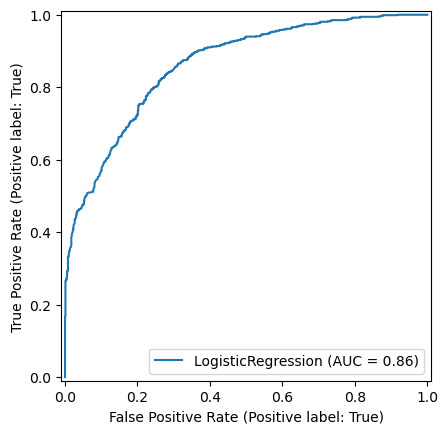

In [252]:
RocCurveDisplay.from_estimator(model,x_valid,y_valid)
plt.show()